In [2]:
from data_generators import get_wgan_data_generator,get_gt_data_generator
from opt_targeted_transfers import get_cond_density_estimator, Dataset, get_nll
from feature_selection import forward_selection
import matplotlib.pyplot as plt

In [4]:
datawrapperpath = 'pickled/datawrapper-maxepochs=5000_lr=0.001_batchsize=256_dropout=0.0.pickle'
generatorpath = 'pickled/generator-maxepochs=5000_lr=0.001_batchsize=256_dropout=0.0.pickle'
f = get_wgan_data_generator(generatorpath, datawrapperpath)

In [5]:
train_df = f(10000, seed=582645)
val_df = f(50000, seed=1)
train_dataset = Dataset(train_df, outcome="consumption_per_capita_per_day", covs=[], weight="hh_wgt")
val_dataset = Dataset(val_df, outcome="consumption_per_capita_per_day", covs=[], weight="hh_wgt")

In [6]:
ordered_features, _ = forward_selection(train_dataset, val_dataset)

yearly_rent 0.604051006897814
ag_b101 0.6997928629163617
anntot_avg 0.7349799986781105
hh_o0a 0.761797878339049
cropshare 0.7778787007228614
h2019_ndvi_max 0.7975024452538166
h2018_ndvi_max 0.8485725215177486
af_bio_1_x 0.8648880281369291
dist_road 0.8874430359926212
ea_lon_mod 0.895823592451347
h2019_wetQstart 0.908904307854356
dist_admarc 0.9159775049650465
srtm_1k 0.9207892177345848
af_bio_12_x 0.9256310438153748
hh_f19 0.9283704576528965
af_bio_8_x 0.9295314510764784
hh_x05 0.9307797969673375
h2018_tot 0.9318733091169907
dist_popcenter 0.9330666513533402
h2018_wetQstart 0.9345763891258302
hh_f11 0.9355157045681152
durable_asset_Coffee table (for sitting room) 0.9362041943017125
hh_f41 0.9368073596437761
ag_i101b 0.9373176582117744
hh_f09 0.9378134557069773
durable_asset_Tape or CD/DVD player; HiFi 0.9380718911413567
ndvi_avg 0.938323034732284
h2019_ndvi_avg 0.938345345043521
hh_f41_oth 0.938349051861058
hh_f12_oth 0.938349051861058
ag_asset_FORK 0.938349051861058
ag_asset_GRASS CUT

In [14]:
ds = [0]
n_bins= [5, 10, 20, 50, 100]
n_knots= [2, 4, 8, 10, 12]
degree= [2, 3, 4, 5]

results = []
for d in ds:
    for nb in n_bins:
        for nk in n_knots:
            for dg in degree:
                train_dataset = Dataset(train_df, outcome="consumption_per_capita_per_day", covs=ordered_features[:d], weight="hh_wgt")
                val_dataset = Dataset(val_df, outcome="consumption_per_capita_per_day", covs=ordered_features[:d], weight="hh_wgt")
                estimator = get_cond_density_estimator(train_dataset, n_bins=nb, n_knots=nk, degree=dg)
                nll = get_nll(val_dataset, estimator)
                results.append({"d": d, "n_bins": nb, "n_knots": nk, "degree": dg, "nll": nll})
            

Fitting conditional densities vs glm spline method...


100%|██████████| 300/300 [00:01<00:00, 219.87it/s, loss=-0.119, val_loss=-0.103]  


Final Theta: tensor([[ 1.7911],
        [-1.8157],
        [-2.2769]], dtype=torch.float64)
Fitting conditional densities vs glm spline method...


100%|██████████| 300/300 [00:01<00:00, 199.36it/s, loss=-0.111, val_loss=-0.0975] 


Final Theta: tensor([[ 1.8704],
        [ 2.7000],
        [-2.8941],
        [ 2.1653]], dtype=torch.float64)
Fitting conditional densities vs glm spline method...


...

Final Theta: tensor([[-1.9540],
        [ 0.2530],
        [-0.0802],
        [ 0.1460],
        [-0.0205],
        [ 0.1690],
        [-0.0036],
        [-0.0117],
        [ 0.0497],
        [ 0.0401],
        [ 0.0271],
        [ 0.0356],
        [ 0.0491],
        [ 1.7810]], dtype=torch.float64)
Fitting conditional densities vs glm spline method...


100%|██████████| 300/300 [00:01<00:00, 190.05it/s, loss=-0.00274, val_loss=-0.00128] 


Final Theta: tensor([[-2.3853],
        [ 0.0904],
        [-0.4279],
        [ 0.2845],
        [-0.1079],
        [ 0.1284],
        [ 0.0309],
        [-0.0422],
        [ 0.0142],
        [ 0.0297],
        [ 0.0057],
        [ 0.1080],
        [-0.5079],
        [ 1.8160],
        [ 2.1641]], dtype=torch.float64)
Fitting conditional densities vs glm spline method...


100%|██████████| 300/300 [00:01<00:00, 210.49it/s, loss=-0.00294, val_loss=-0.00107] 


Final Theta: tensor([[-1.7771],
        [ 0.0571],
        [-1.0772],
        [ 0.4667],
        [-0.1744],
        [ 0.1114],
        [-0.0347],
        [ 0.1445],
        [-0.1969],
        [ 0.1504],
        [-0.1387],
        [ 0.3013],
        [-0.7525],
        [ 1.1736],
        [ 1.5845],
        [ 0.9060]], dtype=torch.float64)


In [12]:
import pandas as pd
df = pd.DataFrame.from_records(results)
df.loc[df['nll'].idxmin()]


d           0.000000
n_bins     50.000000
n_knots    12.000000
degree      2.000000
nll         1.493279
Name: 76, dtype: float64

Fitting conditional densities vs glm spline method...


100%|██████████| 300/300 [00:01<00:00, 222.32it/s, loss=-0.0722, val_loss=-0.059] 


Final Theta: tensor([[-2.7166],
        [ 1.5891],
        [-0.3539],
        [ 0.3781],
        [-0.0258],
        [ 1.4636]], dtype=torch.float64)
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 5.02426495e-01 4.61312191e-01 4.20197886e-01
 3.79083582e-01 3.37969277e-01 2.96854973e-01 2.55740668e-01
 2.14626364e-01 1.73512060e-01 1.52772592e-01 1.46586581e-01
 1.40400569e-01 1.34214557e-01 1.28028545e-01 1.21842533e-01
 1.15656521e-01 1.09470509e-01 1.03284497e-01 9.97646913e-02
 9.99775734e-02 1.00190455e-01 1.00403337e-01 1.00616220e-01
 1.00829102e-01 1.01041984e-01 1.01254866e-01 1.01467748e-01
 1.01407914e-01 1.00529934e-01 9.96519541e-02 9.87739740e-02
 9.78959940e-02 9.70180139e-02 9.61400339e-02 9.52620538e-02
 9.43840737e-02 9.33397564e-02 9.04657286e-02 8.75917008e-02
 8.47176730e-02 8.18436452e-02 7.89696174e-02 7.60955896e-02
 7.32215618e-02 7.03475340e-02 6.74735062e-02 6.52269858e-

(array([2.54386003e-01, 1.28196497e-01, 1.08001142e-01, 6.79868019e-02,
        3.67530018e-02, 1.85646562e-02, 8.40427256e-03, 3.63767021e-03,
        1.12893146e-03, 1.25436904e-04]),
 array([ 0.        ,  1.59442735,  3.18885469,  4.78328228,  6.37770939,
         7.97213697,  9.56656456, 11.16099167, 12.75541878, 14.34984684,
        15.94427395]),
 <BarContainer object of 10 artists>)

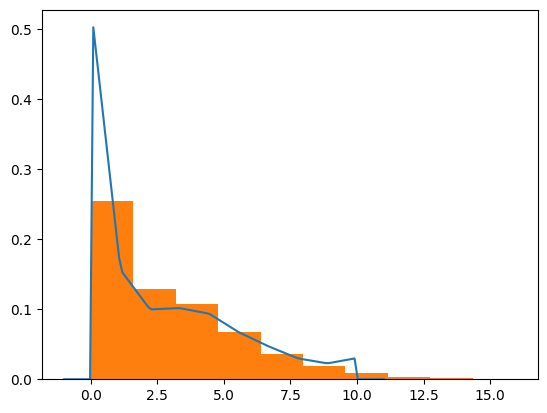

In [32]:
import numpy as np
import matplotlib.pyplot as plt
train_dataset = Dataset(train_df, outcome="consumption_per_capita_per_day", covs=[], weight="hh_wgt")
estimator = get_cond_density_estimator(train_dataset, n_bins=10)
X,y, r = train_dataset.get_data()
cond_dists = estimator(X)
print(cond_dists[0].pdf(np.linspace(-1, 11, 100)))

plt.plot(np.linspace(-1, 11, 100), cond_dists[0].pdf(np.linspace(-1, 11, 100)))
plt.hist(y,density=True, bins=10)



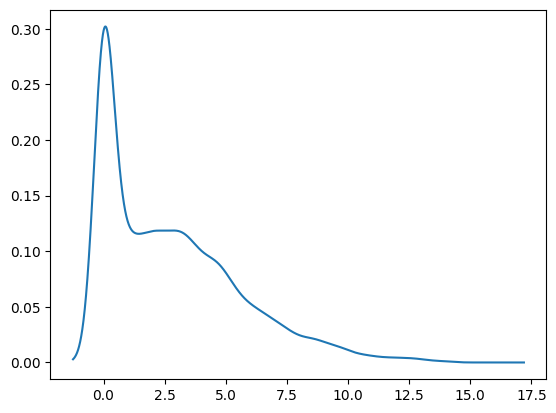

In [24]:
from statsmodels.nonparametric.kde import KDEUnivariate
kde = KDEUnivariate(y)
kde.fit(weights=r, fft=False, adjust=0.8)
plt.plot(kde.support, kde.density)

In [11]:
np.log(cond_dists[0].pdf(np.linspace(0., 10, 100)))

array([-0.12533396, -0.27318234, -0.47107558, -0.71079325, -0.97964453,
       -1.25950079, -1.52763958, -1.76118096, -1.94454251, -2.07483411,
       -2.16026244, -2.21353552, -2.24602258, -2.26583711, -2.27819195,
       -2.28627813, -2.29199216, -2.2964004 , -2.30003807, -2.30312162,
       -2.30569715, -2.307721  , -2.30907044, -2.3094988 , -2.30857154,
       -2.30564183, -2.29993027, -2.29074286, -2.27778666, -2.26145904,
       -2.24295644, -2.22411671, -2.20704155, -2.19365231, -2.18534535,
       -2.1828409 , -2.18621925, -2.19506646, -2.20854287, -2.22537479,
       -2.24412112, -2.26329875, -2.28155532, -2.29793399, -2.31215466,
       -2.32476928, -2.33706747, -2.35071928, -2.36727265, -2.3876873 ,
       -2.41206324, -2.43964907, -2.46913034, -2.49910753, -2.52858733,
       -2.55728153, -2.58558924, -2.61431203, -2.64430029, -2.67624057,
       -2.71066021, -2.74805007, -2.78891246, -2.83359753, -2.88195977,
       -2.93303447, -2.98499407, -3.03555039, -3.08273626, -3.12

(array([4348., 2254., 1715., 1009.,  432.,  165.,   46.,   20.,    6.,
           5.]),
 array([ 0.        ,  1.84851873,  3.69703746,  5.54555607,  7.39407492,
         9.24259377, 11.09111214, 12.93963146, 14.78814983, 16.63666916,
        18.48518753]),
 <BarContainer object of 10 artists>)

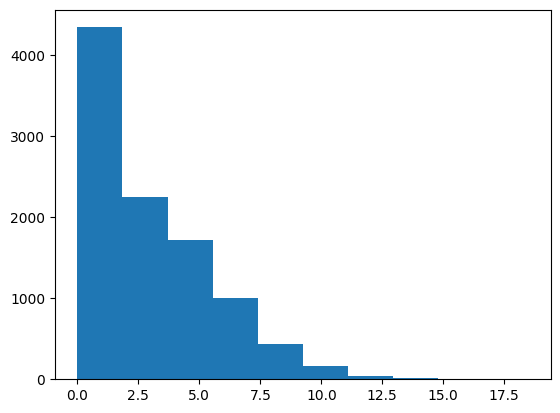

In [19]:
train_df = f(5000, seed=582645)
X_train, y_train, r_train = train_dataset.get_data()
plt.hist(y_train)

(array([2.3192e+04, 1.2268e+04, 8.3320e+03, 4.0140e+03, 1.5360e+03,
        4.6800e+02, 1.3200e+02, 4.7000e+01, 1.0000e+01, 1.0000e+00]),
 array([ 0.        ,  2.04746366,  4.09492731,  6.14239073,  8.18985462,
        10.23731804, 12.28478146, 14.33224487, 16.37970924, 18.42717171,
        20.47463608]),
 <BarContainer object of 10 artists>)

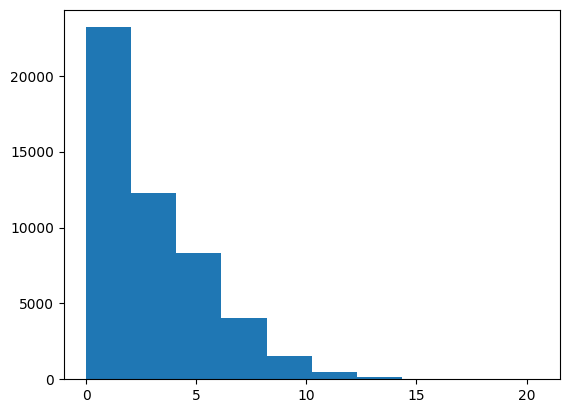

In [28]:
X_val, y_val, r_val = val_dataset.get_data()
plt.hist(y_val, bins=10)